In [ ]:
%pip install pandas matplotlib seaborn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 34.6 MB/s  0:00:00 eta 0:00:01
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]


成功加载数据，共包含 355 篇文献。


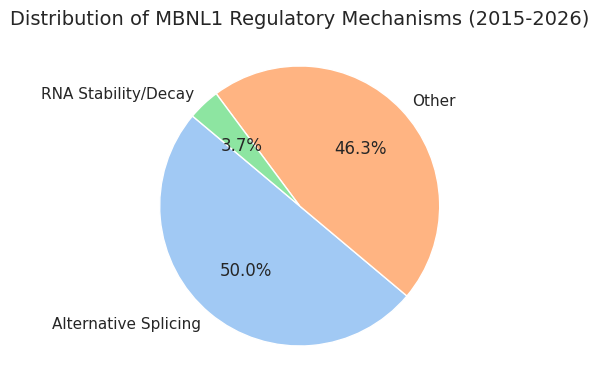

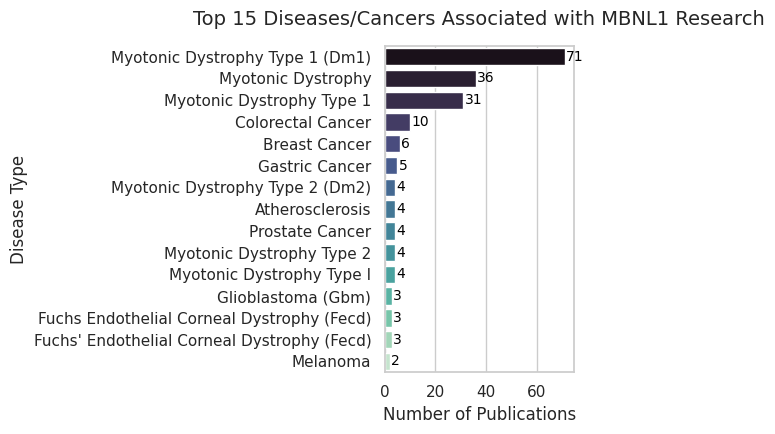

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置漂亮的绘图风格
sns.set_theme(style="whitegrid")
# 解决有时中文字体无法显示的问题（这里图表标题我们尽量用英文显得更学术）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  
plt.rcParams['axes.unicode_minus'] = False 

# 2. 读取我们辛苦跑出来的 355 篇文献数据
# 请确保路径和文件名与你实际保存的一致
csv_path = "data/processed_csv/mbnl1_all_diseases_2015_2026.csv" 
df = pd.read_csv(csv_path)

print(f"成功加载数据，共包含 {len(df)} 篇文献。")

# ==========================================
# 图表 1：MBNL1 调控机制的偏好分布 (饼图)
# ==========================================
plt.figure(figsize=(6, 4))

# 过滤掉提取错误的行，并统计机制数量
mechanism_data = df[~df['Mechanism_Category'].isin(['Error', 'None'])]
mechanism_counts = mechanism_data['Mechanism_Category'].value_counts()

# 绘制饼图
colors = sns.color_palette("pastel")[0:len(mechanism_counts)]
plt.pie(mechanism_counts, 
        labels=mechanism_counts.index, 
        autopct='%1.1f%%', # 显示百分比
        startangle=140, 
        colors=colors,
        shadow=False)
plt.title("Distribution of MBNL1 Regulatory Mechanisms (2015-2026)", fontsize=14, pad=20)
plt.axis('equal') # 保证饼图是圆的
plt.show()


# ==========================================
# 图表 2：MBNL1 相关的核心疾病/癌症模型 Top 15 (条形图)
# ==========================================
plt.figure(figsize=(6, 4.5))

# 数据清洗：过滤掉 "None" (基础研究无疾病模型)、"Error" 和空值
disease_df = df.dropna(subset=['Disease_Type'])
disease_df = disease_df[~disease_df['Disease_Type'].isin(["None", "Error", "Not Mentioned"])]

# 统一大小写，防止大模型有时返回全大写或全小写导致分类重复
disease_df['Disease_Type'] = disease_df['Disease_Type'].str.title()

# 提取排名前 15 的疾病
disease_counts = disease_df['Disease_Type'].value_counts().head(15)

# 绘制水平条形图
ax = sns.barplot(x=disease_counts.values, y=disease_counts.index, 
                    hue=disease_counts.index,  # 按y轴变量分组
                    palette="mako",
                    legend=False)

# 在柱子旁边打上具体的数字标签
for i, v in enumerate(disease_counts.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center', fontsize=10)

plt.title("Top 15 Diseases/Cancers Associated with MBNL1 Research", fontsize=14, pad=15)
plt.xlabel("Number of Publications", fontsize=12)
plt.ylabel("Disease Type", fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
# 过滤出所有被归类为 "Other" 的文献
other_df = df[df['Mechanism_Category'] == 'Other']

# 随机抽查 10 篇，看看大模型总结的 Key_Finding 到底是什么
print(f"共有 {len(other_df)} 篇文章被归为 Other。以下是随机抽查的 10 篇：\n")

# 我们只看标题和大模型提取的核心发现
for index, row in other_df.sample(10, random_state=42).iterrows():
    print(f"📝 标题: {row['Title']}")
    print(f"💡 核心发现: {row['Key_Finding']}")
    print("-" * 60)

共有 162 篇文章被归为 Other。以下是随机抽查的 10 篇：

📝 标题: Therapeutic impact of systemic AAV-mediated RNA interference in a mouse model of myotonic dystrophy.
💡 核心发现: 通过rAAV递送RNAi靶向CUG(exp) mRNA，可显著减轻DM1小鼠模型的病理特征，包括减少异常mRNA、改善肌强直放电、恢复成年剪接模式等，为DM1提供了系统性基因治疗策略。
------------------------------------------------------------
📝 标题: miR-7 Restores Phenotypes in Myotonic Dystrophy Muscle Cells by Repressing Hyperactivated Autophagy.
💡 核心发现: miR-7通过调控自噬和泛素-蛋白酶体系统改善DM1肌肉萎缩表型，其作用独立于MBNL1，提示miR-7恢复是潜在治疗靶点。
------------------------------------------------------------
📝 标题: RAN Translation Regulated by Muscleblind Proteins in Myotonic Dystrophy Type 2.
💡 核心发现: MBNL1通过核滞留CCUG转录本抑制RAN蛋白表达，其功能丧失可能导致毒性蛋白积累，加剧疾病进展。
------------------------------------------------------------
📝 标题: Dynamic docking of small molecules targeting RNA CUG repeats causing myotonic dystrophy type 1.
💡 核心发现: MBNL1被扩展的CUG重复RNA结合而功能受损，导致肌强直性营养不良1型，研究开发了基于物理的动态对接方法以设计靶向RNA的小分子药物来抑制MBNL1结合并改善疾病缺陷。
-----------------------------------------------------

In [3]:
import pandas as pd

# 1. 精准过滤：只保留机制为 "RNA Stability/Decay" 的文献
stability_df = df[df['Mechanism_Category'] == 'RNA Stability/Decay'].copy()
print(f"🎯 极速锁定：在 355 篇文献中，共有 {len(stability_df)} 篇明确研究了 MBNL1 调控 RNA 稳定性。\n")

# 2. 数据展平（Explode）：把合并在同一个单元格里的多个基因拆开
# 因为我们在保存 CSV 时用了 ", ".join()，所以现在要把它们按逗号重新切成列表
stability_df['Target_Genes_List'] = stability_df['Target_Genes'].astype(str).apply(
    lambda x: [g.strip() for g in x.replace('[', '').replace(']', '').replace("'", "").split(',')] 
    if x not in ['[]', 'None', 'nan', '', 'Not Mentioned'] else []
)

# 使用 pandas 极其强大的 explode 函数，把包含多个基因的行“炸”成多行
exploded_genes = stability_df.explode('Target_Genes_List')

# 清洗掉空字符串和无效数据
valid_genes = exploded_genes[exploded_genes['Target_Genes_List'].str.len() > 1]
valid_genes = valid_genes[~valid_genes['Target_Genes_List'].isin(['None', 'Not Mentioned'])]

# 3. 词频统计：谁是这个领域绝对的 C 位靶点？
gene_counts = valid_genes['Target_Genes_List'].value_counts()

print("🔥 核心靶点排行榜：RNA 稳定性方向被验证最多的基因")
print("-" * 50)
print(gene_counts.head(10).to_string())
print("\n" + "=" * 60 + "\n")

# 4. 打印这批核心文献的详细情报，方便你直接去查阅原文
print("📖 核心文献情报清单：\n")
for index, row in stability_df.iterrows():
    print(f"📌 标题: {row['Title']}")
    print(f"🧬 提取靶基因: {row['Target_Genes']}")
    print(f"🦠 涉及疾病: {row['Disease_Type']}")
    print(f"💡 核心发现: {row['Key_Finding']}")
    print("-" * 80)

🎯 极速锁定：在 355 篇文献中，共有 13 篇明确研究了 MBNL1 调控 RNA 稳定性。

🔥 核心靶点排行榜：RNA 稳定性方向被验证最多的基因
--------------------------------------------------
Target_Genes_List
PRKAA2       1
HIF-1α       1
RNF125       1
CENPA        1
Myocardin    1
Cul3         1
Snail        1
DBNL         1
TACC1        1


📖 核心文献情报清单：

📌 标题: Cancer-associated fibroblast-derived exosomal LINC00930 represses cell malignancy and glycolysis by recruiting MBNL1 and elevating PRKAA2 stability in colorectal cancer.
🧬 提取靶基因: PRKAA2
🦠 涉及疾病: Colorectal Cancer
💡 核心发现: MBNL1通过提高PRKAA2的稳定性，介导CAF来源的外泌体LINC00930对结直肠癌进展的抑制作用。
--------------------------------------------------------------------------------
📌 标题: Post-transcriptional control of HIF-1α by MBNL1 restrains hypoxia-driven stemness in GBM.
🧬 提取靶基因: HIF-1α
🦠 涉及疾病: Glioblastoma
💡 核心发现: MBNL1通过结合HIF-1α 3'UTR促进其mRNA快速降解，从而限制HIF-1活性和缺氧诱导的胶质母细胞瘤干细胞特性，为GBM治疗提供新靶点。
--------------------------------------------------------------------------------
📌 标题: RNA‑binding protein MBNL1 regulates tum